# Neural Sentiment Classifier

FFNN, RNN, LSTM and GRU compared on the NLTK Twitter Samples dataset.

---
## Section 1: Data Acquisition & EDA

In [1]:
import os, re, time, random
from collections import Counter

import numpy as np
import pandas as pd

import nltk
for resource in ['twitter_samples', 'stopwords', 'punkt']:
    nltk.download(resource, quiet=True)
from nltk.corpus import twitter_samples
from nltk.tokenize import TweetTokenizer

import gensim.downloader as gensim_api

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt
import seaborn as sns


EMBEDDING_DIM  = 100
INPUT_DIM      = EMBEDDING_DIM + 1     # +1 for the negation flag appended to each token vector
HIDDEN_DIM     = 128
NUM_LAYERS     = 2
DROPOUT        = 0.2
EPOCHS         = 50
PATIENCE       = 6
LEARNING_RATE  = 1e-3
BATCH_SIZE     = 64
WEIGHT_DECAY   = 1e-4
MAX_LEN        = 30
GRAD_CLIP      = 5.0
SEED           = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device   : {'GPU' if torch.cuda.is_available() else 'CPU'}")

Device   : CPU


In [2]:
pos_tweets_raw = twitter_samples.strings('positive_tweets.json')
neg_tweets_raw = twitter_samples.strings('negative_tweets.json')

df = pd.DataFrame({
    'tweet'    : pos_tweets_raw + neg_tweets_raw,
    'label'    : [1] * len(pos_tweets_raw) + [0] * len(neg_tweets_raw),
    'sentiment': ['positive'] * len(pos_tweets_raw) + ['negative'] * len(neg_tweets_raw),
})

df['word_count'] = df['tweet'].apply(lambda x: len(x.split()))
df.head(10)

,tweet,label,sentiment,word_count
0,#FollowFriday @France_Inte @PKuchly57 @Milipol...,1,positive,15
1,@Lamb2ja Hey James! How odd :/ Please call our...,1,positive,24
2,@DespiteOfficial we had a listen last night :)...,1,positive,20
3,@97sides CONGRATS :),1,positive,3
4,yeaaaah yippppy!!! my accnt verified rqst has...,1,positive,21
5,@BhaktisBanter @PallaviRuhail This one is irre...,1,positive,9
6,We don't like to keep our lovely customers wai...,1,positive,21
7,"@Impatientraider On second thought, there’s ju...",1,positive,22
8,"Jgh , but we have to go to Bayan :D bye",1,positive,11
9,"As an act of mischievousness, am calling the E...",1,positive,22


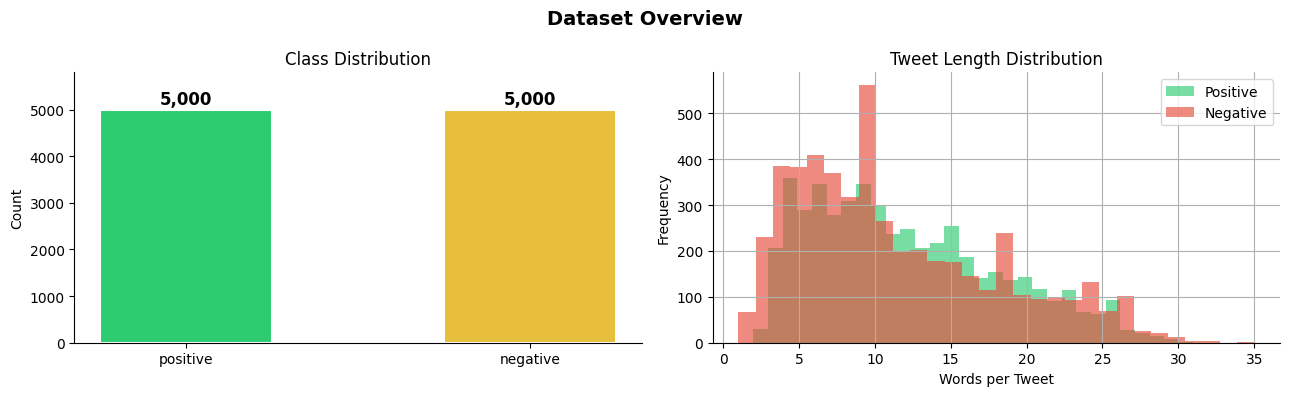

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Dataset Overview', fontsize=14, fontweight='bold')

counts = df['sentiment'].value_counts()
bars = axes[0].bar(counts.index, counts.values,
                   color=['#2ecc71', "#e7bf3c"], edgecolor='white', linewidth=1.5, width=0.5)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                 f"{int(bar.get_height()):,}", ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_title('Class Distribution'); axes[0].set_ylabel('Count')
axes[0].set_ylim(0, 5800); axes[0].spines[['top', 'right']].set_visible(False)

df[df['sentiment'] == 'positive']['word_count'].hist(bins=30, alpha=0.65, color='#2ecc71', label='Positive', ax=axes[1])
df[df['sentiment'] == 'negative']['word_count'].hist(bins=30, alpha=0.65, color='#e74c3c', label='Negative', ax=axes[1])
axes[1].set_title('Tweet Length Distribution'); axes[1].set_xlabel('Words per Tweet')
axes[1].set_ylabel('Frequency'); axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout(); plt.show()

In [4]:
df['char_count'] = df['tweet'].str.len()

print(f"Duplicate tweets : {df['tweet'].duplicated().sum()}")
print(f"Total tweets     : {len(df)}")
print()
print(df.groupby('sentiment')['char_count'].describe()[['mean', 'std', 'min', 'max']].round(1))

Duplicate tweets : 0
Total tweets     : 10000

           mean   std  min    max
sentiment                        
negative   63.4  36.7  7.0  148.0
positive   73.7  36.9  7.0  152.0


---
## Section 2: Data Cleaning & Preprocessing

In [5]:
tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)

URL_PATTERN     = re.compile(r'https?://\S+|www\.\S+')
HTML_PATTERN    = re.compile(r'&[a-z]+;')
HASHTAG_PATTERN = re.compile(r'#')
PUNCT_ONLY_PATT = re.compile(r'^[^\w]+$')

NEGATION_WORDS = {
    'not', 'no', 'never', 'neither', 'nobody', 'nothing', 'nowhere', 'nor',
    "isn't", "isnt", "aren't", "arent", "wasn't", "wasnt", "weren't", "werent",
    "don't", "dont", "doesn't", "doesnt", "didn't", "didnt",
    "can't", "cant", "cannot", "couldn't", "couldnt",
    "won't", "wont", "wouldn't", "wouldnt",
    "shouldn't", "shouldnt", "mustn't", "mustnt",
    "haven't", "havent", "hasn't", "hasnt", "hadn't", "hadnt",
    "hardly", "barely", "scarcely",
}
NEGATION_SCOPE = 4


def apply_negation_marking(tokens):
    marked, scope = [], 0
    for token in tokens:
        if token in {'.', '!', '?', ';'}:
            scope = 0; marked.append(token); continue
        if token in NEGATION_WORDS:
            scope = NEGATION_SCOPE; marked.append(token)
        elif scope > 0:
            marked.append('NOT_' + token); scope -= 1
        else:
            marked.append(token)
    return marked


def base_word(tok):
    return tok[4:] if tok.startswith('NOT_') else tok


def clean_and_tokenize(raw_tweet):
    text   = URL_PATTERN.sub('', raw_tweet)
    text   = HTML_PATTERN.sub('', text)
    text   = HASHTAG_PATTERN.sub('', text)
    tokens = tokenizer.tokenize(text)
    tokens = [t for t in tokens if not PUNCT_ONLY_PATT.match(t)]
    return apply_negation_marking(tokens)

In [6]:
df['tokens']      = df['tweet'].apply(clean_and_tokenize)
df['token_count'] = df['tokens'].apply(len)
df.head(10)

,tweet,label,sentiment,word_count,char_count,tokens,token_count
0,#FollowFriday @France_Inte @PKuchly57 @Milipol...,1,positive,15,111,"[followfriday, for, being, top, engaged, membe...",11
1,@Lamb2ja Hey James! How odd :/ Please call our...,1,positive,24,126,"[hey, james, how, odd, please, call, our, cont...",21
2,@DespiteOfficial we had a listen last night :)...,1,positive,20,107,"[we, had, a, listen, last, night, as, you, ble...",18
3,@97sides CONGRATS :),1,positive,3,20,[congrats],1
4,yeaaaah yippppy!!! my accnt verified rqst has...,1,positive,21,106,"[yeaaah, yipppy, my, accnt, verified, rqst, ha...",20
5,@BhaktisBanter @PallaviRuhail This one is irre...,1,positive,9,103,"[this, one, is, irresistible, flipkartfashionf...",5
6,We don't like to keep our lovely customers wai...,1,positive,21,127,"[we, don't, NOT_like, NOT_to, NOT_keep, NOT_ou...",18
7,"@Impatientraider On second thought, there’s ju...",1,positive,22,130,"[on, second, thought, there, s, just, not, NOT...",21
8,"Jgh , but we have to go to Bayan :D bye",1,positive,11,39,"[jgh, but, we, have, to, go, to, bayan, :D, bye]",10
9,"As an act of mischievousness, am calling the E...",1,positive,22,127,"[as, an, act, of, mischievousness, am, calling...",22


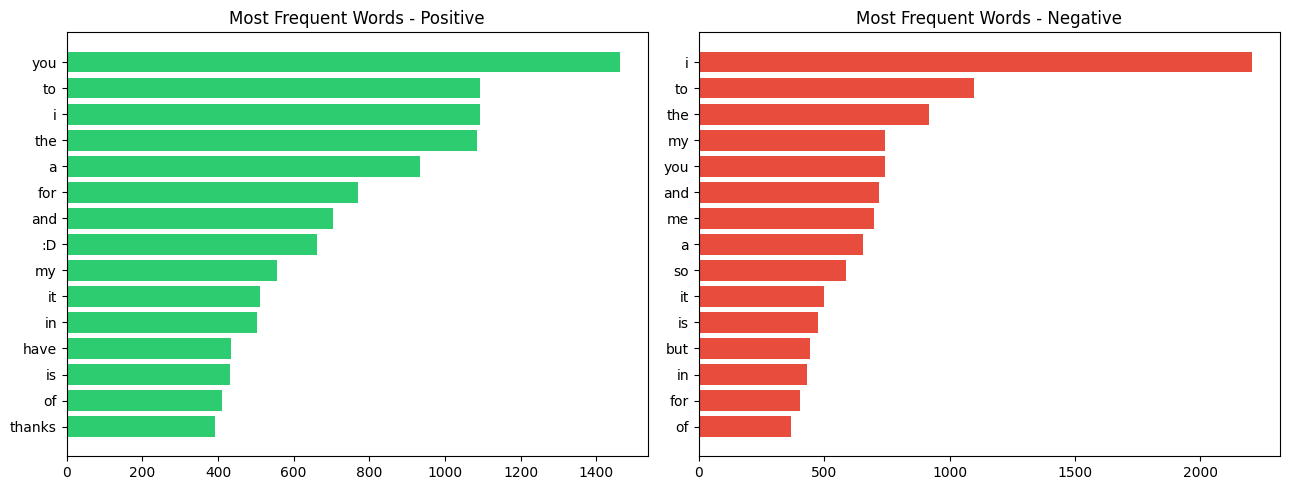

In [7]:
pos_counts = Counter(base_word(t) for toks in df[df['label'] == 1]['tokens'] for t in toks)
neg_counts = Counter(base_word(t) for toks in df[df['label'] == 0]['tokens'] for t in toks)

top_pos = pos_counts.most_common(15)
top_neg = neg_counts.most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh([w for w, _ in top_pos][::-1], [c for _, c in top_pos][::-1], color='#2ecc71')
axes[0].set_title('Most Frequent Words - Positive')
axes[1].barh([w for w, _ in top_neg][::-1], [c for _, c in top_neg][::-1], color='#e74c3c')
axes[1].set_title('Most Frequent Words - Negative')
plt.tight_layout(); plt.show()

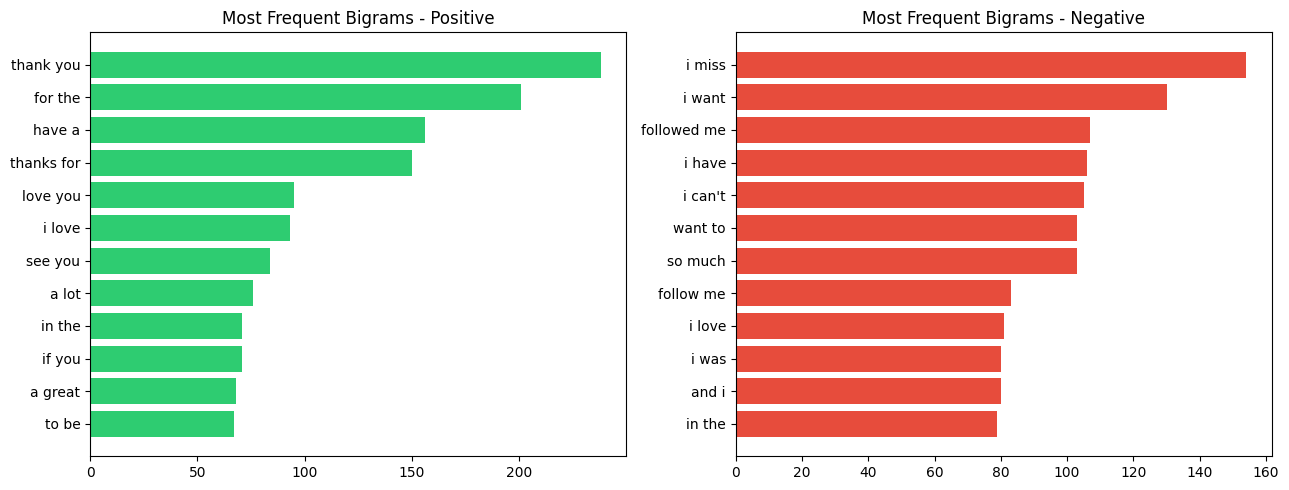

In [8]:
def bigrams(tokens):
    words = [base_word(t) for t in tokens]
    return list(zip(words, words[1:]))

pos_bigrams = Counter(b for toks in df[df['label'] == 1]['tokens'] for b in bigrams(toks))
neg_bigrams = Counter(b for toks in df[df['label'] == 0]['tokens'] for b in bigrams(toks))

top_pos_bg = pos_bigrams.most_common(12)
top_neg_bg = neg_bigrams.most_common(12)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh([' '.join(b) for b, _ in top_pos_bg][::-1], [c for _, c in top_pos_bg][::-1], color='#2ecc71')
axes[0].set_title('Most Frequent Bigrams - Positive')
axes[1].barh([' '.join(b) for b, _ in top_neg_bg][::-1], [c for _, c in top_neg_bg][::-1], color='#e74c3c')
axes[1].set_title('Most Frequent Bigrams - Negative')
plt.tight_layout(); plt.show()

In [9]:
def count_negated(tokens):
    return sum(1 for t in tokens if t.startswith('NOT_'))

df['negated_token_count'] = df['tokens'].apply(count_negated)

print("Avg negated tokens per class:")
print(df.groupby('sentiment')['negated_token_count'].mean().round(3))
print()
print("Tweets with at least one negated token:")
print(df.groupby('sentiment')['negated_token_count'].apply(lambda x: (x > 0).sum()))

Avg negated tokens per class:
sentiment
negative    0.935
positive    0.420
Name: negated_token_count, dtype: float64

Tweets with at least one negated token:
sentiment
negative    1278
positive     580
Name: negated_token_count, dtype: int64


---
## Section 3: Word Embedding Layer

Each token vector is the GloVe embedding of its base word plus one extra dimension flagging whether the token was negated, so words inside a negation scope keep their embedding instead of collapsing to an out-of-vocabulary zero vector.

In [10]:
glove_model = gensim_api.load('glove-twitter-100')

In [11]:
def get_sequence_matrix(tokens, max_len=MAX_LEN):
    mat = np.zeros((max_len, INPUT_DIM), dtype=np.float32)
    for i, tok in enumerate(tokens[:max_len]):
        negated = tok.startswith('NOT_')
        base = base_word(tok)
        if base in glove_model:
            mat[i, :EMBEDDING_DIM] = glove_model[base]
        mat[i, EMBEDDING_DIM] = float(negated)
    return mat


df['sequence']  = df['tokens'].apply(get_sequence_matrix)
df['length']    = df['token_count'].clip(1, MAX_LEN)
df['oov_count'] = df['tokens'].apply(lambda toks: sum(1 for t in toks if base_word(t) not in glove_model))

print(df.groupby('sentiment')[['token_count', 'negated_token_count', 'oov_count']].mean().round(3))

           token_count  negated_token_count  oov_count
sentiment                                             
negative         9.524                0.935      0.673
positive         9.646                0.420      0.791


In [12]:
oov_words = Counter(base_word(t) for toks in df['tokens'] for t in toks if base_word(t) not in glove_model)

print("Most common OOV tokens:")
for word, count in oov_words.most_common(15):
    print(f"  {word:<20} {count}")

Most common OOV tokens:
  :D                   662
  i'm                  526
  it's                 340
  don't                256
  3                    228
  can't                223
  :p                   138
  you're               135
  i'll                 132
  that's               128
  i've                 112
  1                    105
  2                    100
  didn't               88
  we're                60


In [13]:
X       = np.stack(df['sequence'].values).astype(np.float32)
lengths = df['length'].values.astype(np.int64)
y       = df['label'].values.astype(np.float32)

idx = np.arange(len(df))
idx_train, idx_temp = train_test_split(idx, test_size=0.3, random_state=SEED, stratify=y)
idx_val, idx_test   = train_test_split(idx_temp, test_size=0.5, random_state=SEED, stratify=y[idx_temp])

print(f"Train: {len(idx_train):,}  |  Val: {len(idx_val):,}  |  Test: {len(idx_test):,}")


def make_loader(indices, shuffle):
    ds = TensorDataset(
        torch.from_numpy(X[indices]),
        torch.from_numpy(lengths[indices]),
        torch.from_numpy(y[indices]).unsqueeze(1),
    )
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)


train_loader = make_loader(idx_train, True)
val_loader   = make_loader(idx_val, False)
test_loader  = make_loader(idx_test, False)

Train: 7,000  |  Val: 1,500  |  Test: 1,500


---
## Section 4: Model Architectures

FFNN, RNN, LSTM and GRU, all built from the same INPUT_DIM, HIDDEN_DIM, NUM_LAYERS and DROPOUT so the comparison in Section 6 is fair.

In [14]:
class FFNN(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, dropout_rate=DROPOUT):
        super().__init__()
        self.fc1  = nn.Linear(input_dim, hidden_dim * 2)
        self.act  = nn.ReLU()
        self.drop = nn.Dropout(dropout_rate)
        self.fc2  = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x, lengths):
        # masked mean pooling over the real (non-padded) timesteps
        mask   = (torch.arange(x.size(1), device=x.device)[None, :] < lengths[:, None]).unsqueeze(-1)
        pooled = (x * mask).sum(1) / lengths.unsqueeze(1).float()
        h = self.drop(self.act(self.fc1(pooled)))
        return self.fc2(h)

In [15]:
class SentimentRNN(nn.Module):
    def __init__(self, cell, input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS, dropout_rate=DROPOUT):
        super().__init__()
        rnn_cls = {'rnn': nn.RNN, 'lstm': nn.LSTM, 'gru': nn.GRU}[cell]
        self.cell = cell
        self.rnn  = rnn_cls(input_dim, hidden_dim, num_layers=num_layers, batch_first=True,
                             bidirectional=True, dropout=dropout_rate)
        self.drop = nn.Dropout(dropout_rate)
        self.fc   = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        if self.cell == 'lstm':
            _, (h_n, _) = self.rnn(packed)
        else:
            _, h_n = self.rnn(packed)
        h = torch.cat((h_n[-2], h_n[-1]), dim=1)
        return self.fc(self.drop(h))

In [16]:
def build_model(name):
    return FFNN() if name == 'FFNN' else SentimentRNN(name.lower())


MODEL_NAMES = ['FFNN', 'RNN', 'LSTM', 'GRU']

_dummy_x   = torch.zeros(4, MAX_LEN, INPUT_DIM)
_dummy_len = torch.full((4,), MAX_LEN, dtype=torch.long)

for name in MODEL_NAMES:
    torch.manual_seed(SEED)
    m = build_model(name)
    n_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    out = m(_dummy_x, _dummy_len)
    assert out.shape == (4, 1)
    print(f"{name:<6} params: {n_params:,}")

FFNN   params: 26,369


RNN    params: 158,209


LSTM   params: 632,065
GRU    params: 474,113


---
## Section 5: Training

Early stopping on validation loss, with the best-epoch weights restored at the end of training.

In [17]:
def train_model(model, name, epochs=EPOCHS, patience=PATIENCE):
    model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0
    history = {'epoch': [], 'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for Xb, Lb, yb in train_loader:
            Xb, Lb, yb = Xb.to(device), Lb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb, Lb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            running_loss += loss.item() * Xb.size(0)
        train_loss = running_loss / len(idx_train)

        model.eval()
        val_loss = 0.0
        preds, truths = [], []
        with torch.no_grad():
            for Xb, Lb, yb in val_loader:
                Xb, Lb, yb = Xb.to(device), Lb.to(device), yb.to(device)
                out = model(Xb, Lb)
                val_loss += criterion(out, yb).item() * Xb.size(0)
                preds.extend((torch.sigmoid(out).cpu().numpy() >= 0.5).astype(int).flatten())
                truths.extend(yb.cpu().numpy().astype(int).flatten())
        val_loss /= len(idx_val)
        val_acc = accuracy_score(truths, preds)

        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

        if epoch % 5 == 0 or epoch == 1:
            print(f"{name:<6} epoch {epoch:3d}/{epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history).set_index('epoch')

In [18]:
trained_models = {}
histories = {}
train_times = {}

for name in MODEL_NAMES:
    torch.manual_seed(SEED)
    model = build_model(name)
    t0 = time.time()
    trained_models[name], histories[name] = train_model(model, name)
    train_times[name] = time.time() - t0
    print(f"{name} done in {train_times[name]:.1f}s\n")

FFNN   epoch   1/50 | train_loss=0.5859 | val_loss=0.5395 | val_acc=0.7167


FFNN   epoch   5/50 | train_loss=0.4724 | val_loss=0.5087 | val_acc=0.7513


FFNN   epoch  10/50 | train_loss=0.4364 | val_loss=0.4982 | val_acc=0.7513


FFNN   epoch  15/50 | train_loss=0.4077 | val_loss=0.4960 | val_acc=0.7547


FFNN done in 16.1s



...

LSTM   epoch   5/50 | train_loss=0.4076 | val_loss=0.4915 | val_acc=0.7527


LSTM done in 90.4s



GRU    epoch   1/50 | train_loss=0.5348 | val_loss=0.5192 | val_acc=0.7373


GRU    epoch   5/50 | train_loss=0.4043 | val_loss=0.4964 | val_acc=0.7533


GRU done in 78.8s



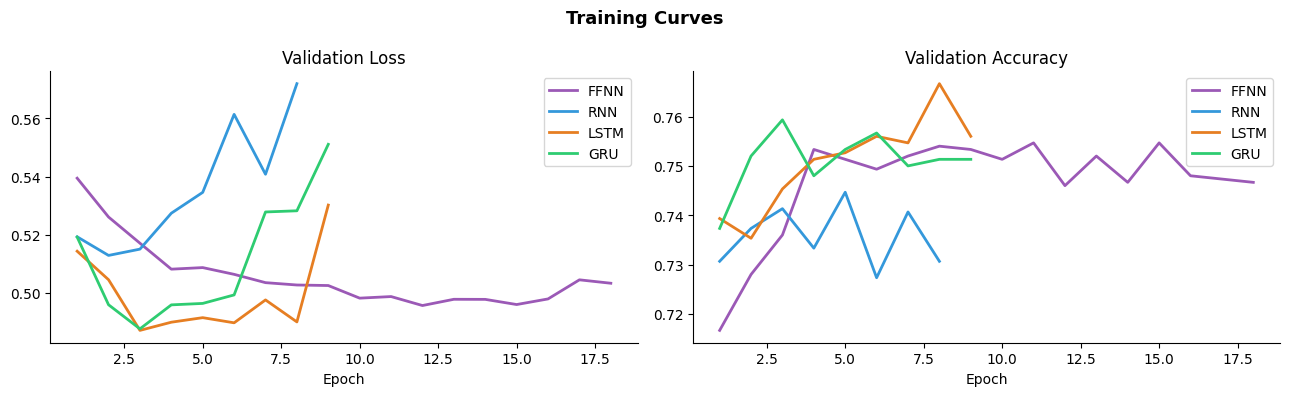

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Training Curves', fontsize=13, fontweight='bold')

colors = {'FFNN': '#9b59b6', 'RNN': '#3498db', 'LSTM': '#e67e22', 'GRU': '#2ecc71'}

for name in MODEL_NAMES:
    h = histories[name]
    axes[0].plot(h.index, h['val_loss'], label=name, color=colors[name], linewidth=2)
    axes[1].plot(h.index, h['val_acc'], label=name, color=colors[name], linewidth=2)

axes[0].set_title('Validation Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)
axes[1].set_title('Validation Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout(); plt.show()

---
## Section 6: Evaluation & Comparison

In [20]:
def evaluate(model, loader):
    model.eval()
    probs, preds, truths = [], [], []
    with torch.no_grad():
        for Xb, Lb, yb in loader:
            out = torch.sigmoid(model(Xb.to(device), Lb.to(device))).cpu().numpy().flatten()
            probs.extend(out)
            preds.extend((out >= 0.5).astype(int))
            truths.extend(yb.numpy().astype(int).flatten())
    acc = accuracy_score(truths, preds)
    p, r, f1, _ = precision_recall_fscore_support(truths, preds, average='binary')
    return {'accuracy': acc, 'precision': p, 'recall': r, 'f1': f1}, probs, preds, truths


results = []
test_outputs = {}
for name in MODEL_NAMES:
    metrics, probs, preds, truths = evaluate(trained_models[name], test_loader)
    n_params = sum(p.numel() for p in trained_models[name].parameters() if p.requires_grad)
    results.append({'model': name, 'params': n_params, 'train_time_s': round(train_times[name], 1),
                     'best_epoch': int(histories[name]['val_loss'].idxmin()), **metrics})
    test_outputs[name] = (probs, preds, truths)

results_df = pd.DataFrame(results).set_index('model').round(4)
results_df

,params,train_time_s,best_epoch,accuracy,precision,recall,f1
model,,,,,,,
FFNN,26369,16.1,12,0.7680,0.7724,0.7600,0.7661
RNN,158209,25.9,2,0.7747,0.7718,0.7800,0.7759
LSTM,632065,90.4,3,0.7827,0.7865,0.7760,0.7812
GRU,474113,78.8,3,0.7853,0.7948,0.7693,0.7818


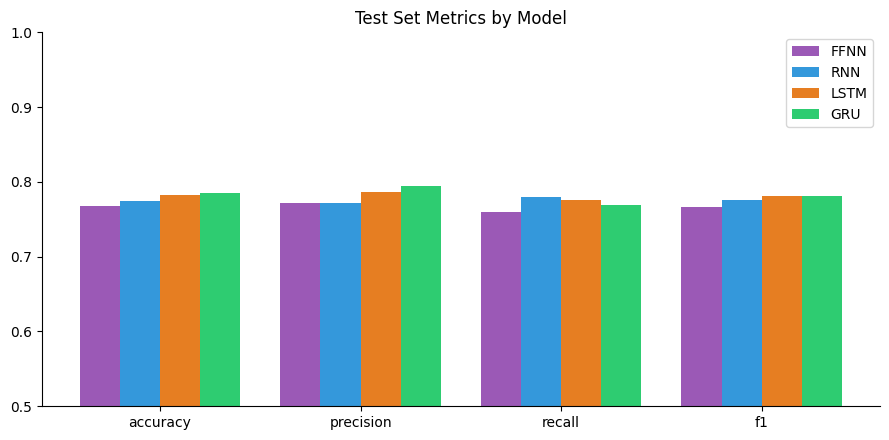

In [21]:
fig, ax = plt.subplots(figsize=(9, 4.5))
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
x = np.arange(len(metrics_to_plot))
width = 0.2

for i, name in enumerate(MODEL_NAMES):
    values = [results_df.loc[name, metric] for metric in metrics_to_plot]
    ax.bar(x + i * width, values, width, label=name, color=colors[name])

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0.5, 1.0)
ax.set_title('Test Set Metrics by Model')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

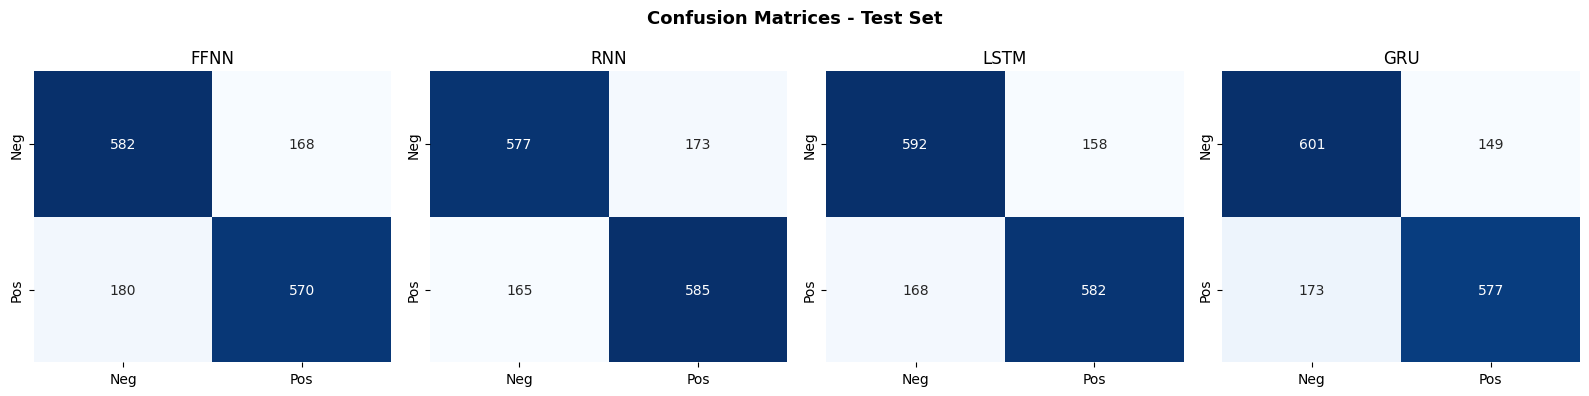

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Confusion Matrices - Test Set', fontsize=13, fontweight='bold')

for ax, name in zip(axes, MODEL_NAMES):
    _, preds, truths = test_outputs[name]
    cm = confusion_matrix(truths, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'], ax=ax)
    ax.set_title(name)

plt.tight_layout(); plt.show()

In [23]:
best_model_name = results_df['f1'].idxmax()
best_probs, best_preds, best_truths = test_outputs[best_model_name]

print(f"Best model: {best_model_name}")
print(classification_report(best_truths, best_preds, target_names=['Negative (0)', 'Positive (1)'], digits=4))

Best model: GRU
              precision    recall  f1-score   support

Negative (0)     0.7765    0.8013    0.7887       750
Positive (1)     0.7948    0.7693    0.7818       750

    accuracy                         0.7853      1500
   macro avg     0.7856    0.7853    0.7853      1500
weighted avg     0.7856    0.7853    0.7853      1500



In [24]:
torch.save({
    'models': {name: trained_models[name].state_dict() for name in MODEL_NAMES},
    'hyperparameters': {
        'embedding_dim': EMBEDDING_DIM, 'hidden_dim': HIDDEN_DIM, 'num_layers': NUM_LAYERS,
        'max_len': MAX_LEN, 'epochs': EPOCHS, 'learning_rate': LEARNING_RATE, 'batch_size': BATCH_SIZE,
    },
    'results': results_df.to_dict(),
    'best_model': best_model_name,
}, 'sentiment_models.pt')

print(f"Models saved -> sentiment_models.pt")

Models saved -> sentiment_models.pt


---
## Section 7: Interactive Testing

Change `my_text` or `MODEL_TO_TEST` and re-run the last cell.

In [25]:
def predict_sentiment(raw_text, model_name=None, threshold=0.5):
    model_name = model_name or best_model_name
    model = trained_models[model_name]

    tokens = clean_and_tokenize(raw_text)
    mat    = get_sequence_matrix(tokens)
    length = max(1, min(len(tokens), MAX_LEN))

    x = torch.from_numpy(mat).unsqueeze(0).to(device)
    l = torch.tensor([length], dtype=torch.long)

    model.eval()
    with torch.no_grad():
        prob = torch.sigmoid(model(x, l)).item()

    predicted = 1 if prob >= threshold else 0
    return {
        'raw_text'       : raw_text,
        'model'          : model_name,
        'tokens'         : tokens,
        'negated_tokens' : [t for t in tokens if t.startswith('NOT_')],
        'oov_count'      : sum(1 for t in tokens if base_word(t) not in glove_model),
        'probability'    : round(prob, 4),
        'predicted_label': predicted,
        'sentiment'      : 'Positive' if predicted == 1 else 'Negative',
    }

In [26]:
sample_inputs = [
    "I absolutely love this product, it made my day!",
    "This is absolutely terrible. I wasted my money.",
    "this movie isn't good at all",
    "not bad actually",
    "never been so disappointed in my life",
]

df_predictions = pd.DataFrame([predict_sentiment(t) for t in sample_inputs])[
    ['raw_text', 'model', 'tokens', 'negated_tokens', 'oov_count', 'probability', 'sentiment']
]

df_predictions

,raw_text,model,tokens,negated_tokens,oov_count,probability,sentiment
0,"I absolutely love this product, it made my day!",GRU,"[i, absolutely, love, this, product, it, made,...",[],0,0.7245,Positive
1,This is absolutely terrible. I wasted my money.,GRU,"[this, is, absolutely, terrible, i, wasted, my...",[],0,0.0483,Negative
2,this movie isn't good at all,GRU,"[this, movie, isn't, NOT_good, NOT_at, NOT_all]","[NOT_good, NOT_at, NOT_all]",1,0.4460,Negative
3,not bad actually,GRU,"[not, NOT_bad, NOT_actually]","[NOT_bad, NOT_actually]",0,0.0575,Negative
4,never been so disappointed in my life,GRU,"[never, NOT_been, NOT_so, NOT_disappointed, NO...","[NOT_been, NOT_so, NOT_disappointed, NOT_in]",0,0.0319,Negative


In [ ]:
MODEL_TO_TEST = best_model_name   
my_text = "hgagy is a great guy"

result = predict_sentiment(my_text, model_name=MODEL_TO_TEST)

print(f"Model          : {result['model']}")
print(f"Input          : {result['raw_text']}")
print(f"Tokens         : {result['tokens']}")
print(f"Negated tokens : {result['negated_tokens']}")
print(f"OOV words      : {result['oov_count']}")
print(f"P(Positive)    : {result['probability']:.4f}")
print(f"Sentiment      : {result['sentiment']}")

Model          : GRU
Input          : hgagy is a great guy
Tokens         : ['hgagy', 'is', 'a', 'great', 'guy']
Negated tokens : []
OOV words      : 1
P(Positive)    : 0.7572
Sentiment      : Positive
